# NB07: THINGS RT Fitting

**Purpose:** Fit the free Rational Taper model (k=2) to all 17 THINGS galaxies
that passed QC in Block 2. Flag spatially resolved galaxies (Rt < R_max),
compute g(Rt) diagnostics, and store results in the database.

**Expected outputs:**
- 17 RT model fits stored in `model_fits` table with `data_source='THINGS'`
- Resolved fraction comparable to Paper 2's 70.3% (though small-N variance expected)
- g(Rt) distribution for resolved THINGS galaxies

**Inputs:** Radial profiles from NB04 (overlap) and NB06 (non-overlap), already in DB.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.physics import (
    fit_rational_taper, compute_transition_diagnostics,
    compute_v_bary, A0_HALF, ACCEL_TO_MKS,
)
from src.database import (
    get_engine, get_session, query_profiles_as_dataframe,
    insert_model_fit, delete_fits, Galaxy,
)

a0_half_mks = A0_HALF * ACCEL_TO_MKS  # 6.00e-11 m/s^2

results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

engine = get_engine()
session = get_session(engine)

## 1. Load THINGS Galaxy List

In [2]:
things_galaxies = (
    session.query(Galaxy)
    .filter(Galaxy.data_source == "THINGS")
    .order_by(Galaxy.galaxy_id)
    .all()
)
things_ids = [g.galaxy_id for g in things_galaxies]
print(f"THINGS galaxies to fit: {len(things_ids)}")
for gid in things_ids:
    print(f"  {gid}")

THINGS galaxies to fit: 17
  DDO154_THINGS
  IC2574_THINGS
  NGC2366_THINGS
  NGC2403_THINGS
  NGC2841_THINGS
  NGC2903_THINGS
  NGC2976_THINGS
  NGC3031_THINGS
  NGC3198_THINGS
  NGC3521_THINGS
  NGC3621_THINGS
  NGC4736_THINGS
  NGC5055_THINGS
  NGC6946_THINGS
  NGC7331_THINGS
  NGC7793_THINGS
  NGC925_THINGS


## 2. Fit Free RT Model to All THINGS Galaxies

Uses `src.physics.fit_rational_taper()` with the same multi-start optimizer
and bounds as Paper 2. Existing THINGS RT fits are deleted first to ensure
idempotent re-runs.

In [3]:
# Clear any existing THINGS RT fits (idempotent re-run)
for gid in things_ids:
    delete_fits(session, galaxy_id=gid, model_name="rational_taper")

print("Cleared existing THINGS RT fits.")
print()

# Fit each galaxy
fit_results = []

for gid in things_ids:
    df = query_profiles_as_dataframe(session, gid)
    if df.empty:
        print(f"  {gid}: NO PROFILES -- skipping")
        continue

    radius = df["radius_kpc"].values
    v_obs = df["v_obs"].values
    v_err = df["v_err"].values
    v_bary = df["v_baryon_total"].values

    result = fit_rational_taper(
        radius, v_obs, v_err, v_bary,
        galaxy_id=gid,
        method_version="v1_rational_taper",
    )

    # Store in database
    insert_model_fit(session, result.to_dict())

    r_max = float(radius[-1])
    resolved = result.converged and result.param2 < r_max

    fit_results.append({
        "galaxy_id": gid,
        "omega": result.param1,
        "omega_err": result.param1_err,
        "Rt": result.param2,
        "Rt_err": result.param2_err,
        "chi2_r": result.reduced_chi_squared,
        "bic": result.bic,
        "rmse": result.residuals_rmse,
        "n_points": result.n_points,
        "converged": result.converged,
        "R_max": r_max,
        "resolved": resolved,
        "Rt_over_Rmax": result.param2 / r_max if result.converged else np.nan,
    })

    status = "RESOLVED" if resolved else ("UNRESOLVED" if result.converged else "FAILED")
    print(f"  {gid:25s}: omega={result.param1:7.3f}  Rt={result.param2:7.2f}  "
          f"chi2_r={result.reduced_chi_squared:6.2f}  [{status}]")

fits_df = pd.DataFrame(fit_results)
print(f"\nTotal fits: {len(fits_df)}")
print(f"Converged:  {fits_df['converged'].sum()}")
print(f"Resolved:   {fits_df['resolved'].sum()}")

Cleared existing THINGS RT fits.

  DDO154_THINGS            : omega= 12.094  Rt=   4.82  chi2_r=  0.30  [RESOLVED]
  IC2574_THINGS            : omega=  5.916  Rt=  47.06  chi2_r=  0.60  [UNRESOLVED]
  NGC2366_THINGS           : omega= 12.206  Rt=   4.78  chi2_r=  0.68  [RESOLVED]
  NGC2403_THINGS           : omega= 16.766  Rt=   6.53  chi2_r=  0.76  [RESOLVED]
  NGC2841_THINGS           : omega= 32.544  Rt=   5.29  chi2_r=  0.45  [RESOLVED]
  NGC2903_THINGS           : omega=  5.964  Rt=  59.49  chi2_r=  3.08  [UNRESOLVED]
  NGC2976_THINGS           : omega= 35.614  Rt=   0.47  chi2_r=  0.38  [RESOLVED]
  NGC3031_THINGS           : omega= 58.928  Rt=   1.53  chi2_r=  3.90  [RESOLVED]
  NGC3198_THINGS           : omega= 13.375  Rt=   7.30  chi2_r=  0.73  [RESOLVED]
  NGC3521_THINGS           : omega= 11.860  Rt=  13.52  chi2_r=  0.66  [RESOLVED]
  NGC3621_THINGS           : omega= 21.855  Rt=   4.49  chi2_r=  0.90  [RESOLVED]
  NGC4736_THINGS           : omega=200.000  Rt=   0.22  chi2

## 3. Transition Diagnostics for Resolved Galaxies

Compute g(Rt) = V_model(Rt)^2 / Rt for each resolved galaxy using
`src.physics.compute_transition_diagnostics()`.

In [4]:
resolved_mask = fits_df["resolved"].values
resolved_df = fits_df[resolved_mask].copy()

diag_rows = []
for _, row in resolved_df.iterrows():
    gid = row["galaxy_id"]
    df = query_profiles_as_dataframe(session, gid)
    radius = df["radius_kpc"].values
    v_bary = df["v_baryon_total"].values

    diag = compute_transition_diagnostics(
        radius, v_bary, row["omega"], row["Rt"]
    )
    diag["galaxy_id"] = gid
    diag["omega"] = row["omega"]
    diag["Rt"] = row["Rt"]
    diag["R_max"] = row["R_max"]
    diag["Rt_over_Rmax"] = row["Rt_over_Rmax"]
    diag["chi2_r"] = row["chi2_r"]
    diag["n_points"] = row["n_points"]
    # Convert g_obs from km^2/s^2/kpc to m/s^2
    diag["g_Rt_mks"] = diag["g_obs"] * ACCEL_TO_MKS
    diag_rows.append(diag)

diag_df = pd.DataFrame(diag_rows)

# Report
print(f"Resolved THINGS galaxies: {len(diag_df)}")
print()
print(f"{'Galaxy':25s} {'Rt':>7s} {'R_max':>7s} {'Rt/Rmax':>8s} "
      f"{'g(Rt) [m/s^2]':>15s} {'g/a0_half':>10s} {'chi2_r':>7s} {'N':>4s}")
print("-" * 95)
for _, r in diag_df.iterrows():
    ratio = r["g_Rt_mks"] / a0_half_mks
    print(f"{r['galaxy_id']:25s} {r['Rt']:7.2f} {r['R_max']:7.2f} {r['Rt_over_Rmax']:8.3f} "
          f"{r['g_Rt_mks']:15.4e} {ratio:10.3f} {r['chi2_r']:7.2f} {int(r['n_points']):4d}")

Resolved THINGS galaxies: 10

Galaxy                         Rt   R_max  Rt/Rmax   g(Rt) [m/s^2]  g/a0_half  chi2_r    N
-----------------------------------------------------------------------------------------------
DDO154_THINGS                4.82    5.86    0.823      1.4797e-11      0.247    0.30   43
NGC2366_THINGS               4.78    5.99    0.797      2.2281e-11      0.371    0.68   62
NGC2403_THINGS               6.53   17.65    0.370      7.6741e-11      1.279    0.76  286
NGC2841_THINGS               5.29   51.61    0.103      5.6190e-10      9.365    0.45  141
NGC2976_THINGS               0.47    2.25    0.209      6.2300e-11      1.038    0.38   36
NGC3031_THINGS               1.53   14.80    0.104             nan        nan    3.90  117
NGC3198_THINGS               7.30   37.73    0.193      9.7956e-11      1.633    0.73   94
NGC3521_THINGS              13.52   17.69    0.764      1.0514e-10      1.752    0.66   77
NGC3621_THINGS               4.49   25.77    0.174     

## 4. Summary Statistics

In [5]:
n_total = len(fits_df)
n_converged = int(fits_df["converged"].sum())
n_resolved = len(diag_df)
resolved_frac = n_resolved / n_total * 100

# Filter out NaN g(Rt) values
g_valid = diag_df["g_Rt_mks"].dropna()
n_valid_g = len(g_valid)

if n_valid_g > 0:
    median_g = g_valid.median()
    ratio_median = median_g / a0_half_mks
    offset_pct = (ratio_median - 1) * 100

    log_g = np.log10(g_valid.values)
    p16, p50, p84 = np.percentile(log_g, [16, 50, 84])
    scatter_raw = (p84 - p16) / 2.0

    median_rt = diag_df["Rt"].median()
    median_rt_ratio = diag_df["Rt_over_Rmax"].median()
else:
    median_g = ratio_median = offset_pct = scatter_raw = np.nan
    median_rt = median_rt_ratio = np.nan

print("THINGS RT Fitting Summary")
print("=" * 55)
print(f"  Total galaxies:        {n_total}")
print(f"  Converged:             {n_converged}")
print(f"  Resolved (Rt < Rmax):  {n_resolved}  ({resolved_frac:.1f}%)")
print(f"  Valid g(Rt):           {n_valid_g}")
print()
print(f"  Paper 2 resolved frac: 70.3% (N=98/139 converged)")
print(f"  THINGS resolved frac:  {resolved_frac:.1f}% (N={n_resolved}/{n_total})")
print()
if n_valid_g > 0:
    print(f"  Median g(Rt):          {median_g:.4e} m/s^2")
    print(f"  a0/2:                  {a0_half_mks:.4e} m/s^2")
    print(f"  Ratio (median / a0_2): {ratio_median:.4f}")
    print(f"  Offset from a0/2:      {offset_pct:+.1f}%")
    print(f"  Raw scatter (dex):     {scatter_raw:.3f}")
    print(f"  Median Rt:             {median_rt:.2f} kpc")
    print(f"  Median Rt/Rmax:        {median_rt_ratio:.3f}")
else:
    print("  No valid g(Rt) values -- cannot compute statistics.")

THINGS RT Fitting Summary
  Total galaxies:        17
  Converged:             17
  Resolved (Rt < Rmax):  10  (58.8%)
  Valid g(Rt):           8

  Paper 2 resolved frac: 70.3% (N=98/139 converged)
  THINGS resolved frac:  58.8% (N=10/17)

  Median g(Rt):          8.7348e-11 m/s^2
  a0/2:                  6.0003e-11 m/s^2
  Ratio (median / a0_2): 1.4557
  Offset from a0/2:      +45.6%
  Raw scatter (dex):     0.346
  Median Rt:             4.80 kpc
  Median Rt/Rmax:        0.201


## 5. g(Rt) Distribution

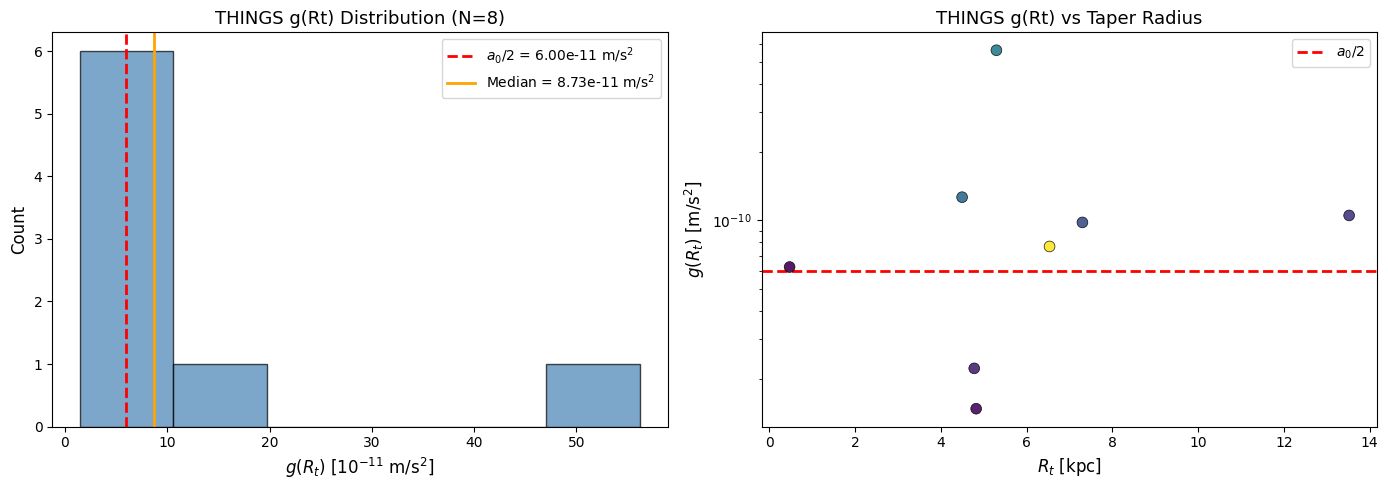

In [6]:
if n_valid_g > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: g(Rt) histogram
    ax = axes[0]
    g_plot = g_valid.values * 1e11
    ax.hist(g_plot, bins=max(6, n_valid_g // 2), edgecolor="black",
            alpha=0.7, color="steelblue")
    ax.axvline(a0_half_mks * 1e11, color="red", linestyle="--", linewidth=2,
               label=f"$a_0/2$ = {a0_half_mks:.2e} m/s$^2$")
    ax.axvline(median_g * 1e11, color="orange", linestyle="-", linewidth=2,
               label=f"Median = {median_g:.2e} m/s$^2$")
    ax.set_xlabel(r"$g(R_t)$ [$10^{-11}$ m/s$^2$]", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"THINGS g(Rt) Distribution (N={n_valid_g})", fontsize=13)
    ax.legend(fontsize=10)

    # Right: g(Rt) vs Rt
    ax = axes[1]
    ax.scatter(diag_df["Rt"], diag_df["g_Rt_mks"],
               c=diag_df["n_points"], cmap="viridis", edgecolors="k",
               linewidth=0.5, s=60, alpha=0.9, zorder=3)
    ax.axhline(a0_half_mks, color="red", linestyle="--", linewidth=2,
               label=f"$a_0/2$", zorder=2)
    ax.set_xlabel("$R_t$ [kpc]", fontsize=12)
    ax.set_ylabel("$g(R_t)$ [m/s$^2$]", fontsize=12)
    ax.set_yscale("log")
    ax.set_title("THINGS g(Rt) vs Taper Radius", fontsize=13)
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(results_dir / "NB07_things_g_Rt.png", dpi=150)
    plt.show()
else:
    print("No valid g(Rt) values to plot.")

## 6. Rotation Curve Fits — All Galaxies

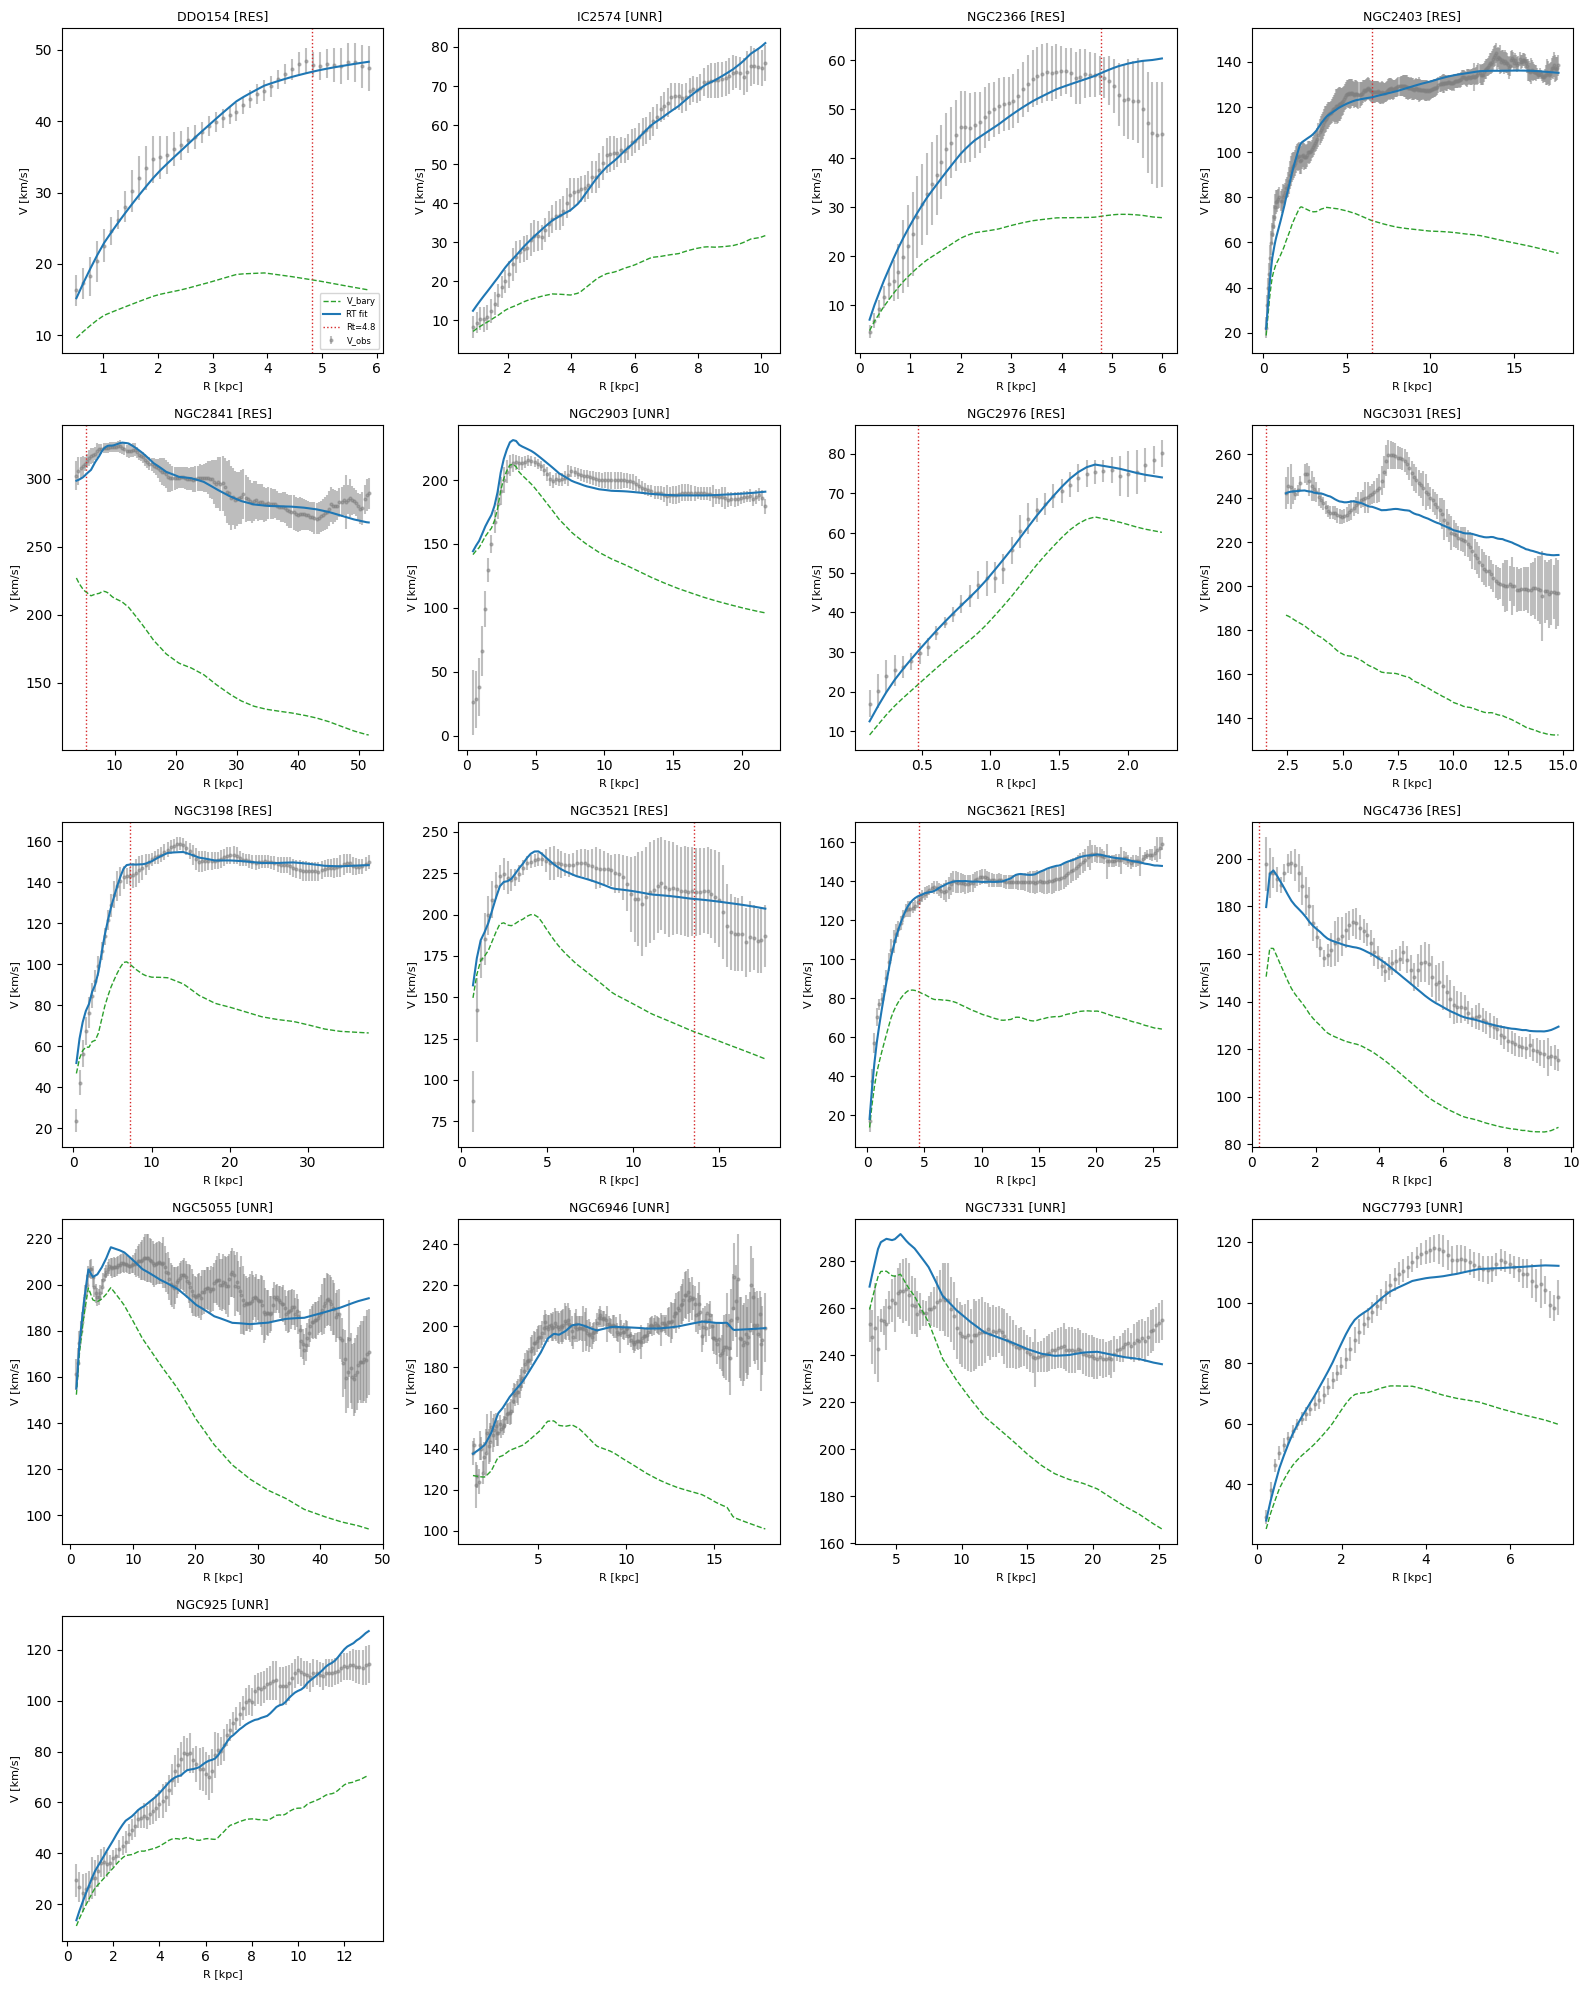

In [7]:
from src.physics import rt_model_velocity

n_gal = len(things_ids)
ncols = 4
nrows = (n_gal + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)

for i, gid in enumerate(things_ids):
    ax = axes[i // ncols][i % ncols]
    df = query_profiles_as_dataframe(session, gid)
    r = df["radius_kpc"].values
    v_obs = df["v_obs"].values
    v_err = df["v_err"].values
    v_bary = df["v_baryon_total"].values

    row = fits_df[fits_df["galaxy_id"] == gid].iloc[0]

    ax.errorbar(r, v_obs, yerr=v_err, fmt="o", ms=2, color="grey",
                alpha=0.5, label="V_obs", zorder=1)
    ax.plot(r, v_bary, "--", color="C2", linewidth=1, label="V_bary", zorder=2)

    if row["converged"]:
        v_model = rt_model_velocity(r, v_bary, row["omega"], row["Rt"])
        ax.plot(r, v_model, "-", color="C0", linewidth=1.5, label="RT fit", zorder=3)
        if row["resolved"]:
            ax.axvline(row["Rt"], color="C3", linestyle=":", linewidth=1,
                       label=f"Rt={row['Rt']:.1f}", zorder=2)

    status = "RES" if row["resolved"] else ("UNR" if row["converged"] else "FAIL")
    ax.set_title(f"{gid.replace('_THINGS','')} [{status}]", fontsize=9)
    ax.set_xlabel("R [kpc]", fontsize=8)
    ax.set_ylabel("V [km/s]", fontsize=8)
    if i == 0:
        ax.legend(fontsize=6, loc="lower right")

for j in range(n_gal, nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.tight_layout()
plt.savefig(results_dir / "NB07_things_rc_fits.png", dpi=150)
plt.show()

## 7. Unresolved Galaxy Analysis

For galaxies where Rt >= R_max (unresolved) or fits failed, document the reason
and whether this is expected given the galaxy's properties.

In [8]:
unresolved = fits_df[~fits_df["resolved"]].copy()

if len(unresolved) > 0:
    print(f"Unresolved or failed galaxies: {len(unresolved)}")
    print()
    print(f"{'Galaxy':25s} {'Converged':>10s} {'omega':>8s} {'Rt':>8s} "
          f"{'R_max':>8s} {'Rt/Rmax':>8s}")
    print("-" * 75)
    for _, r in unresolved.iterrows():
        conv = "Yes" if r["converged"] else "No"
        omega_str = f"{r['omega']:.3f}" if r["converged"] else "--"
        rt_str = f"{r['Rt']:.2f}" if r["converged"] else "--"
        ratio_str = f"{r['Rt_over_Rmax']:.3f}" if r["converged"] else "--"
        print(f"{r['galaxy_id']:25s} {conv:>10s} {omega_str:>8s} {rt_str:>8s} "
              f"{r['R_max']:8.2f} {ratio_str:>8s}")
else:
    print("All galaxies are spatially resolved.")

Unresolved or failed galaxies: 7

Galaxy                     Converged    omega       Rt    R_max  Rt/Rmax
---------------------------------------------------------------------------
IC2574_THINGS                    Yes    5.916    47.06    10.12    4.649
NGC2903_THINGS                   Yes    5.964    59.49    21.73    2.738
NGC5055_THINGS                   Yes    2.827   135.97    47.76    2.847
NGC6946_THINGS                   Yes    8.574    31.76    17.90    1.774
NGC7331_THINGS                   Yes    3.333   126.14    25.23    5.000
NGC7793_THINGS                   Yes   13.664     8.27     7.14    1.159
NGC925_THINGS                    Yes    5.714    41.55    13.07    3.179


## 8. Comparison with Paper 2 Resolved Fraction

In [9]:
print("Resolved Fraction Comparison")
print("=" * 45)
print(f"  Paper 2 (SPARC):  70.3% (98 / 139 converged)")
print(f"  THINGS:           {resolved_frac:.1f}% ({n_resolved} / {n_total})")
print()

# Note: the pre-registration expected ~70% resolution rate
# yielding ~13 resolved from 19 galaxies. With 17 galaxies
# (after QC exclusions), we expect ~12 resolved.
expected_resolved = round(0.703 * n_total)
print(f"  Expected at 70.3% rate: ~{expected_resolved} resolved")
print(f"  Actual:                  {n_resolved} resolved")
diff = abs(n_resolved - expected_resolved)
if diff <= 3:
    print(f"  -> Within expected small-N variation.")
else:
    print(f"  -> Deviation of {diff} from expected -- investigate.")

Resolved Fraction Comparison
  Paper 2 (SPARC):  70.3% (98 / 139 converged)
  THINGS:           58.8% (10 / 17)

  Expected at 70.3% rate: ~12 resolved
  Actual:                  10 resolved
  -> Within expected small-N variation.


## 9. Gate Check and Export

In [10]:
checks = {
    "All 17 galaxies fitted": len(fits_df) == 17,
    "All fits converged": int(fits_df["converged"].sum()) == 17,
    "At least 8 valid g(Rt)": n_valid_g >= 8,
}

# Note: some resolved galaxies may have NaN g(Rt) if Rt falls below R_min
# (baryonic interpolation fails). These are "resolved" in the Rt < R_max sense
# but excluded from the g(Rt) analysis. This is expected for galaxies with
# large inner data gaps (e.g., NGC 3031) or degenerate fits (e.g., NGC 4736).
n_nan_g = n_resolved - n_valid_g
if n_nan_g > 0:
    print(f"Note: {n_nan_g} resolved galaxies have NaN g(Rt) "
          f"(Rt below innermost data point).")
    print()

print("GATE CHECK: NB07 -- THINGS RT Fitting")
print("=" * 55)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "WARN"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("  >>> NB07 COMPLETE -- proceed to NB08 <<<")
else:
    print("  >>> NB07 has warnings -- review before proceeding <<<")

# Export results
fits_df.to_csv(results_dir / "NB07_things_rt_fits.csv", index=False)
if n_valid_g > 0:
    diag_df.to_csv(results_dir / "NB07_things_diagnostics.csv", index=False)
print(f"\nResults saved to results/NB07_things_rt_fits.csv")
print(f"Diagnostics saved to results/NB07_things_diagnostics.csv")

session.close()

Note: 2 resolved galaxies have NaN g(Rt) (Rt below innermost data point).

GATE CHECK: NB07 -- THINGS RT Fitting
  [PASS] All 17 galaxies fitted
  [PASS] All fits converged
  [PASS] At least 8 valid g(Rt)

  >>> NB07 COMPLETE -- proceed to NB08 <<<

Results saved to results/NB07_things_rt_fits.csv
Diagnostics saved to results/NB07_things_diagnostics.csv
